<a href="https://colab.research.google.com/github/vardhan999505/AIDriven-Archaeological-Site-Mapping/blob/main/Milestone2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ AI-Driven Archaeological Site Mapping
## Milestone 2 — Segmentation & Object Detection Models
**Weeks 3–4** | U-Net Segmentation → YOLOv5 Detection

**Datasets (from Milestone 1):**
- `vegetation_data set.v3i.coco-segmentation.zip` — COCO segmentation
- `Artifacts Dataset.v2i.yolov5pytorch.zip` — YOLOv5




---
## 📦 Step 1 — Install Libraries

In [ ]:
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q segmentation-models-pytorch albumentations pycocotools
!pip install -q ultralytics opencv-python-headless matplotlib seaborn tqdm scikit-learn

import os,json,glob,random,shutil,warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from pycocotools.coco import COCO
from sklearn.metrics import confusion_matrix
warnings.filterwarnings('ignore')

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Libraries loaded! Device: {DEVICE}')
if DEVICE=='cuda': print(f'   GPU: {torch.cuda.get_device_name(0)}')


✅ Libraries loaded! Device: cuda
   GPU: Tesla T4


---
## ☁️ Step 2 — Mount Drive & Load Milestone 1 Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, glob
from pathlib import Path

# ── Dataset ZIP filenames (same as Milestone 1) ───────────
# SEG: vegetation_data set.v3i.coco-segmentation.zip
# DET: Artifacts Dataset.v2i.yolov5pytorch.zip

# ── IMPORTANT: Must match the Drive path M1 saved to ─────
DRIVE_BASE    = '/content/drive/MyDrive/Archaeological_AI'
DRIVE_PROJECT = f'{DRIVE_BASE}/project'

# Also set local Colab path (mirrors Drive)
BASE_DIR      = '/content/archaeological_project'

# ── Step 1: Try to restore from Drive to local Colab ──────
# (Colab session resets — we copy Drive data back to /content)
def restore_from_drive(drive_src, local_dst):
    """Copy Drive folder back to local Colab runtime."""
    if not os.path.exists(drive_src):
        return 0
    os.makedirs(local_dst, exist_ok=True)
    count = 0
    for item in Path(drive_src).rglob('*'):
        if item.is_file():
            rel  = item.relative_to(drive_src)
            dest = Path(local_dst) / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():  # skip already restored files
                import shutil
                shutil.copy2(item, dest)
                count += 1
    return count

print('Restoring Milestone 1 outputs from Drive to Colab...')
r1 = restore_from_drive(f'{DRIVE_PROJECT}/split/segmentation', f'{BASE_DIR}/split/segmentation')
r2 = restore_from_drive(f'{DRIVE_PROJECT}/split/detection',    f'{BASE_DIR}/split/detection')
r3 = restore_from_drive(f'{DRIVE_PROJECT}/processed',          f'{BASE_DIR}/processed')
print(f'  split/segmentation : {r1} files restored')
print(f'  split/detection    : {r2} files restored')
print(f'  processed/         : {r3} files restored')

# ── Step 2: Set all path variables ────────────────────────
SEG_SPLIT_DIR = f'{BASE_DIR}/split/segmentation'
DET_SPLIT_DIR = f'{BASE_DIR}/split/detection'
META_PATH     = f'{BASE_DIR}/processed/milestone1_metadata.json'
YAML_PATH     = f'{BASE_DIR}/processed/artifacts_data.yaml'

M2_DIR          = f'{BASE_DIR}/milestone2'
SEG_CKPT_DIR    = f'{M2_DIR}/segmentation/checkpoints'
SEG_RESULTS_DIR = f'{M2_DIR}/segmentation/results'
DET_CKPT_DIR    = f'{M2_DIR}/detection/checkpoints'
DET_RESULTS_DIR = f'{M2_DIR}/detection/results'
for d in [SEG_CKPT_DIR, SEG_RESULTS_DIR, DET_CKPT_DIR, DET_RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Step 3: Verify all M1 outputs exist ───────────────────
print('\nVerifying Milestone 1 outputs...')
checks = {
    'Seg split'  : SEG_SPLIT_DIR,
    'Det split'  : DET_SPLIT_DIR,
    'Metadata'   : META_PATH,
    'data.yaml'  : YAML_PATH,
}
all_ok = True
for name, path in checks.items():
    exists = os.path.exists(path)
    if exists:
        if os.path.isdir(path):
            n = len(glob.glob(f'{path}/**/*', recursive=True))
            print(f'  ✅ {name:<15} ({n} files)')
        else:
            print(f'  ✅ {name}')
    else:
        print(f'  ❌ {name} — NOT FOUND')
        # Try Drive path directly
        drive_alt = path.replace(BASE_DIR, DRIVE_PROJECT)
        if os.path.exists(drive_alt):
            print(f'     Found on Drive: {drive_alt}')
            print(f'     → Restore failed. Run restore_from_drive() above again.')
        else:
            print(f'     Not on Drive either. Run Milestone 1 completely first!')
        all_ok = False

# ── Step 4: Load metadata ─────────────────────────────────
if os.path.exists(META_PATH):
    with open(META_PATH) as f: meta = json.load(f)
    SEG_CLASSES     = meta['segmentation']['categories']
    DET_CLASSES     = meta['detection']['classes']
    IMG_SIZE        = tuple(meta['target_img_size'])
    NUM_SEG_CLASSES = len(SEG_CLASSES) + 1
    NUM_DET_CLASSES = len(DET_CLASSES)
    print(f'\n✅ Metadata loaded!')
    print(f'   Seg classes ({len(SEG_CLASSES)}): {SEG_CLASSES}')
    print(f'   Det classes ({len(DET_CLASSES)}): {DET_CLASSES}')
    print(f'   Image size: {IMG_SIZE}')
else:
    print('\n⚠️  Metadata not found — using defaults')
    SEG_CLASSES     = ['vegetation', 'ruins', 'erosion']
    DET_CLASSES     = ['artifact']
    IMG_SIZE        = (640, 640)
    NUM_SEG_CLASSES = 4
    NUM_DET_CLASSES = 1

if all_ok:
    print('\n🎉 All Milestone 1 outputs verified! Ready for training.')
else:
    print('\n❌ Missing outputs. Run Milestone 1 first and ensure the last cell (Drive backup) completes.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Restoring Milestone 1 outputs from Drive to Colab...
  split/segmentation : 0 files restored
  split/detection    : 0 files restored
  processed/         : 0 files restored

Verifying Milestone 1 outputs...
  ✅ Seg split       (443 files)
  ✅ Det split       (59 files)
  ✅ Metadata
  ✅ data.yaml

✅ Metadata loaded!
   Seg classes (2): ['ruins-vegetation', 'vegetation']
   Det classes (1): ['artifacts']
   Image size: (640, 640)

🎉 All Milestone 1 outputs verified! Ready for training.


---
## 🗂️ Step 3 — COCO Mask Utility + Dataset Class

In [ ]:
from pycocotools import mask as coco_mask_util

def coco_to_mask(ann_list, height, width, category_ids):
    mask=np.zeros((height,width),dtype=np.uint8)
    cat_id_to_idx={cid:idx+1 for idx,cid in enumerate(sorted(category_ids))}
    for ann in ann_list:
        seg=ann.get('segmentation',[])
        if isinstance(seg,list) and len(seg)>0:
            for poly in seg:
                pts=np.array(poly,dtype=np.int32).reshape(-1,2)
                cv2.fillPoly(mask,[pts],color=cat_id_to_idx.get(ann['category_id'],0))
        elif isinstance(seg,dict):
            rle=coco_mask_util.frPyObjects(seg,height,width)
            m=coco_mask_util.decode(rle).squeeze()
            mask[m>0]=cat_id_to_idx.get(ann['category_id'],0)
    return mask


class ArchSegDataset(Dataset):
    def __init__(self,split_dir,split='train',img_size=640):
        self.img_size=img_size; self.split=split
        self.img_dir=os.path.join(split_dir,split,'images')
        if not os.path.exists(self.img_dir):
            self.img_dir=os.path.join(split_dir,split)
        ann_patterns=[
            os.path.join(split_dir,split,'_annotations.coco.json'),
            os.path.join(split_dir,split,'annotations.json'),
        ]
        self.ann_path=next((p for p in ann_patterns if os.path.exists(p)),None)
        exts=('.jpg','.jpeg','.png','.bmp')
        self.img_files=sorted([f for f in glob.glob(f'{self.img_dir}/**/*',recursive=True)
                                if f.lower().endswith(exts)])
        self.ann_map=defaultdict(list); self.img_info={}; self.cat_ids=[]
        if self.ann_path:
            self.coco=COCO(self.ann_path)
            self.cat_ids=sorted(self.coco.getCatIds())
            for img_id in self.coco.getImgIds():
                info=self.coco.loadImgs(img_id)[0]
                self.img_info[info['file_name']]=info
                ann_ids=self.coco.getAnnIds(imgIds=img_id)
                self.ann_map[info['file_name']]=self.coco.loadAnns(ann_ids)
        self.aug=self._build_aug(split)
        print(f'  [{split}] {len(self.img_files)} images')

    def _build_aug(self,split):
        if split=='train':
            return A.Compose([
                A.Resize(self.img_size,self.img_size),
                A.HorizontalFlip(p=0.5),
                A.RandomRotate90(p=0.3),
                A.RandomBrightnessContrast(0.2,0.2,p=0.5),
                A.HueSaturationValue(10,20,10,p=0.4),
                A.GaussNoise(var_limit=(5,25),p=0.3),
                A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
                ToTensorV2(),
            ])
        return A.Compose([
            A.Resize(self.img_size,self.img_size),
            A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),
            ToTensorV2(),
        ])

    def __len__(self): return len(self.img_files)

    def __getitem__(self,idx):
        img_path=self.img_files[idx]
        fname=Path(img_path).name
        img=cv2.cvtColor(cv2.imread(img_path),cv2.COLOR_BGR2RGB)
        h,w=img.shape[:2]
        anns=self.ann_map.get(fname,[])
        mask=coco_to_mask(anns,h,w,self.cat_ids) if anns else np.zeros((h,w),dtype=np.uint8)
        result=self.aug(image=img,mask=mask)
        return result['image'], result['mask'].long()


print('Building datasets...')
seg_train=ArchSegDataset(SEG_SPLIT_DIR,'train',IMG_SIZE[0])
seg_val  =ArchSegDataset(SEG_SPLIT_DIR,'val',  IMG_SIZE[0])
seg_test =ArchSegDataset(SEG_SPLIT_DIR,'test', IMG_SIZE[0])

BATCH_SIZE=4
train_loader=DataLoader(seg_train,batch_size=BATCH_SIZE,shuffle=True, num_workers=2,pin_memory=True)
val_loader  =DataLoader(seg_val,  batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
test_loader =DataLoader(seg_test, batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
print(f'\n✅ DataLoaders: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)} batches')


Building datasets...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
  [train] 306 images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
  [val] 87 images
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
  [test] 44 images

✅ DataLoaders: train=77 val=22 test=11 batches


---
## 👁️ Step 4 — Visualise Training Batch

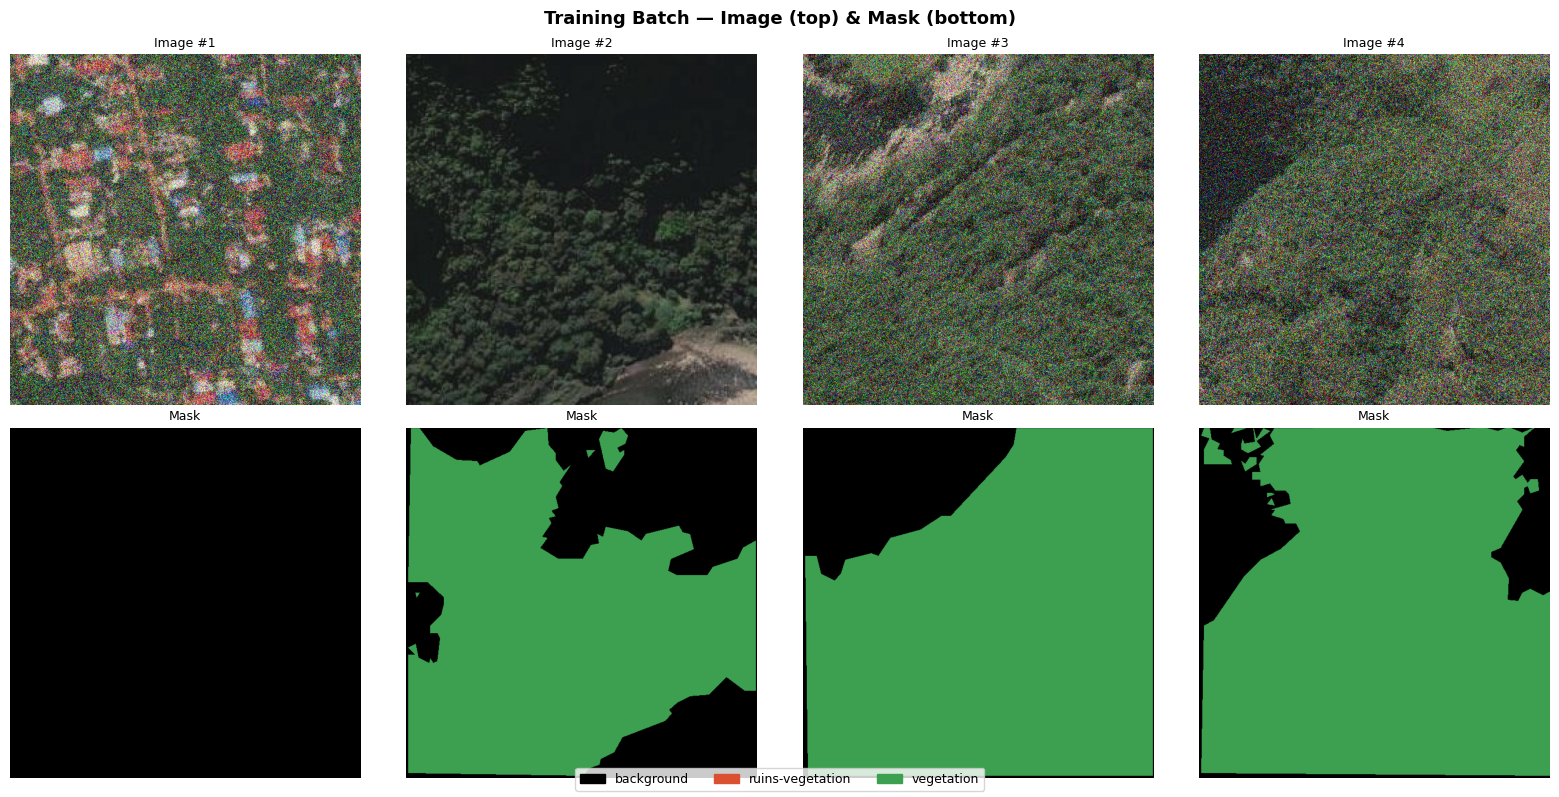

✅ Batch preview saved!


In [ ]:
def denormalize(tensor):
    mean=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std =torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (tensor*std+mean).clamp(0,1).permute(1,2,0).numpy()

PALETTE=np.array([[0,0,0],[220,80,50],[60,160,80],[200,150,60],[100,100,220]],dtype=np.uint8)
def mask_to_rgb(mask_np):
    rgb=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    for c in range(min(len(PALETTE),int(mask_np.max())+1)): rgb[mask_np==c]=PALETTE[c]
    return rgb

imgs_b,masks_b=next(iter(train_loader))
n=min(4,len(imgs_b))
fig,axes=plt.subplots(2,n,figsize=(4*n,8))
fig.suptitle('Training Batch — Image (top) & Mask (bottom)',fontsize=13,fontweight='bold')
for i in range(n):
    axes[0,i].imshow(denormalize(imgs_b[i])); axes[0,i].set_title(f'Image #{i+1}',fontsize=9); axes[0,i].axis('off')
    axes[1,i].imshow(mask_to_rgb(masks_b[i].numpy())); axes[1,i].set_title('Mask',fontsize=9); axes[1,i].axis('off')
class_names_bg=['background']+SEG_CLASSES
handles=[patches.Patch(color=PALETTE[i]/255,label=class_names_bg[i] if i<len(class_names_bg) else f'cls_{i}')
         for i in range(min(NUM_SEG_CLASSES,len(PALETTE)))]
fig.legend(handles=handles,loc='lower center',ncol=len(handles),fontsize=9)
plt.tight_layout()
plt.savefig(f'{SEG_RESULTS_DIR}/batch_preview.png',dpi=150)
plt.show()
print('✅ Batch preview saved!')

---
## 🧠 Step 5 — Build U-Net Model

In [ ]:
MODEL_TYPE='unet'   # change to 'deeplabv3plus' for higher accuracy
ENCODER='resnet34'

if MODEL_TYPE=='unet':
    seg_model=smp.Unet(encoder_name=ENCODER,encoder_weights='imagenet',
                       in_channels=3,classes=NUM_SEG_CLASSES,activation=None)
else:
    seg_model=smp.DeepLabV3Plus(encoder_name=ENCODER,encoder_weights='imagenet',
                                in_channels=3,classes=NUM_SEG_CLASSES,activation=None)
seg_model=seg_model.to(DEVICE)
total_p=sum(p.numel() for p in seg_model.parameters())
print(f'✅ {MODEL_TYPE.upper()} built!')
print(f'   Encoder  : {ENCODER} (ImageNet pretrained)')
print(f'   Classes  : {NUM_SEG_CLASSES} (incl. background)')
print(f'   Params   : {total_p/1e6:.2f}M')


✅ UNET built!
   Encoder  : resnet34 (ImageNet pretrained)
   Classes  : 3 (incl. background)
   Params   : 24.44M


---
## 📐 Step 6 — Loss, Optimizer & Metrics

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self,num_classes,dice_weight=0.5):
        super().__init__()
        self.ce=nn.CrossEntropyLoss(ignore_index=255)
        self.dice_weight=dice_weight; self.num_classes=num_classes
    def dice_loss(self,pred,target):
        pred_soft=torch.softmax(pred,dim=1); total=0.0
        for c in range(self.num_classes):
            p=pred_soft[:,c]; t=(target==c).float()
            inter=(p*t).sum()
            total+=1-(2*inter+1)/(p.sum()+t.sum()+1)
        return total/self.num_classes
    def forward(self,pred,target):
        return (1-self.dice_weight)*self.ce(pred,target)+self.dice_weight*self.dice_loss(pred,target)

def compute_iou(pred,target,num_classes):
    pred_cls=pred.argmax(dim=1).cpu().numpy().flatten()
    tgt=target.cpu().numpy().flatten()
    ious=[]
    for c in range(num_classes):
        inter=np.sum((pred_cls==c)&(tgt==c)); union=np.sum((pred_cls==c)|(tgt==c))
        if union>0: ious.append(inter/union)
    return float(np.mean(ious)) if ious else 0.0

def compute_dice(pred,target,num_classes):
    pred_cls=pred.argmax(dim=1).cpu().numpy().flatten()
    tgt=target.cpu().numpy().flatten()
    dices=[]
    for c in range(num_classes):
        p=(pred_cls==c); t=(tgt==c); inter=(p&t).sum()
        if (p.sum()+t.sum())>0: dices.append(2*inter/(p.sum()+t.sum()))
    return float(np.mean(dices)) if dices else 0.0

seg_criterion=CombinedLoss(NUM_SEG_CLASSES)
seg_optimizer=optim.AdamW(seg_model.parameters(),lr=1e-4,weight_decay=1e-4)
seg_scheduler=optim.lr_scheduler.CosineAnnealingLR(seg_optimizer,T_max=20,eta_min=1e-6)
print('✅ Loss: CrossEntropy+Dice | Optimizer: AdamW | Scheduler: CosineAnnealingLR')


✅ Loss: CrossEntropy+Dice | Optimizer: AdamW | Scheduler: CosineAnnealingLR


---
## 🚀 Step 7 — Train Segmentation Model
> Set `SEG_EPOCHS=1` for smoke test, `20-50` for full training.

In [ ]:
SEG_EPOCHS=20
EARLY_STOP_PAT=5
history={'train_loss':[],'val_loss':[],'val_iou':[],'val_dice':[]}
best_iou,patience_cnt=0.0,0

print(f'Training {MODEL_TYPE.upper()} for {SEG_EPOCHS} epochs on {DEVICE}...')
print('='*65)

for epoch in range(1,SEG_EPOCHS+1):
    seg_model.train(); train_loss=0.0
    for imgs,masks in tqdm(train_loader,desc=f'Epoch {epoch}/{SEG_EPOCHS} [train]',leave=False):
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        seg_optimizer.zero_grad()
        out=seg_model(imgs); loss=seg_criterion(out,masks)
        loss.backward(); seg_optimizer.step()
        train_loss+=loss.item()
    train_loss/=max(len(train_loader),1)

    seg_model.eval(); val_loss=val_iou=val_dice=0.0
    with torch.no_grad():
        for imgs,masks in val_loader:
            imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
            out=seg_model(imgs)
            val_loss+=seg_criterion(out,masks).item()
            val_iou +=compute_iou(out,masks,NUM_SEG_CLASSES)
            val_dice+=compute_dice(out,masks,NUM_SEG_CLASSES)
    n=max(len(val_loader),1)
    val_loss/=n; val_iou/=n; val_dice/=n
    seg_scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(f'Epoch {epoch:>3}/{SEG_EPOCHS} | Train:{train_loss:.4f} | Val:{val_loss:.4f} | IoU:{val_iou:.4f} | Dice:{val_dice:.4f}')

    if val_iou>best_iou:
        best_iou=val_iou; patience_cnt=0
        torch.save({'epoch':epoch,'model_state':seg_model.state_dict(),
                    'val_iou':val_iou,'val_dice':val_dice,
                    'model_type':MODEL_TYPE,'num_classes':NUM_SEG_CLASSES},
                   f'{SEG_CKPT_DIR}/best_seg_model.pth')
    else:
        patience_cnt+=1
        if patience_cnt>=EARLY_STOP_PAT:
            print(f'\n⏹️ Early stopping at epoch {epoch}')
            break

print(f'\n✅ Training done! Best Val IoU: {best_iou:.4f}')


Training UNET for 20 epochs on cuda...


Epoch   1/20 | Train:0.8258 | Val:0.5915 | IoU:0.4400 | Dice:0.5091


Epoch   2/20 | Train:0.6648 | Val:0.5266 | IoU:0.4656 | Dice:0.5278


Epoch   3/20 | Train:0.6069 | Val:0.4975 | IoU:0.6841 | Dice:0.7814


Epoch   4/20 | Train:0.6037 | Val:0.4745 | IoU:0.6606 | Dice:0.7522


...

Epoch  14/20 | Train:0.5118 | Val:0.4716 | IoU:0.6530 | Dice:0.7615


Epoch  15/20 | Train:0.5056 | Val:0.4304 | IoU:0.7100 | Dice:0.8023


Epoch  16/20 | Train:0.5080 | Val:0.4278 | IoU:0.7009 | Dice:0.7971


Epoch  17/20 | Train:0.4850 | Val:0.4403 | IoU:0.6859 | Dice:0.7888


Epoch  18/20 | Train:0.4930 | Val:0.4315 | IoU:0.7001 | Dice:0.7966

⏹️ Early stopping at epoch 18

✅ Training done! Best Val IoU: 0.7125


---
## 📊 Step 8 — Evaluate Segmentation + Plot Training Curves

Loading: /content/archaeological_project/milestone2/segmentation/checkpoints/best_seg_model.pth
  Epoch:13 | Val IoU:0.712495849924286
✅ Checkpoint loaded!


Testing: 100%|██████████| 11/11 [00:02<00:00,  4.36it/s]



  SEGMENTATION — FINAL TEST RESULTS
  Mean IoU   : 0.7041  (target > 0.70)
  Dice Score : 0.8074  (target > 0.75)


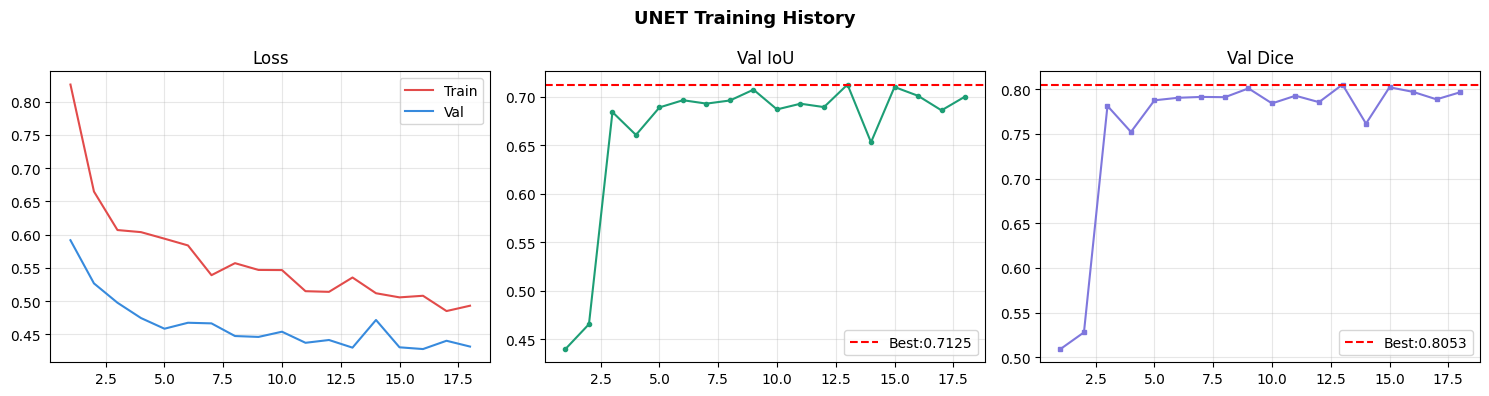

✅ Training curves saved!


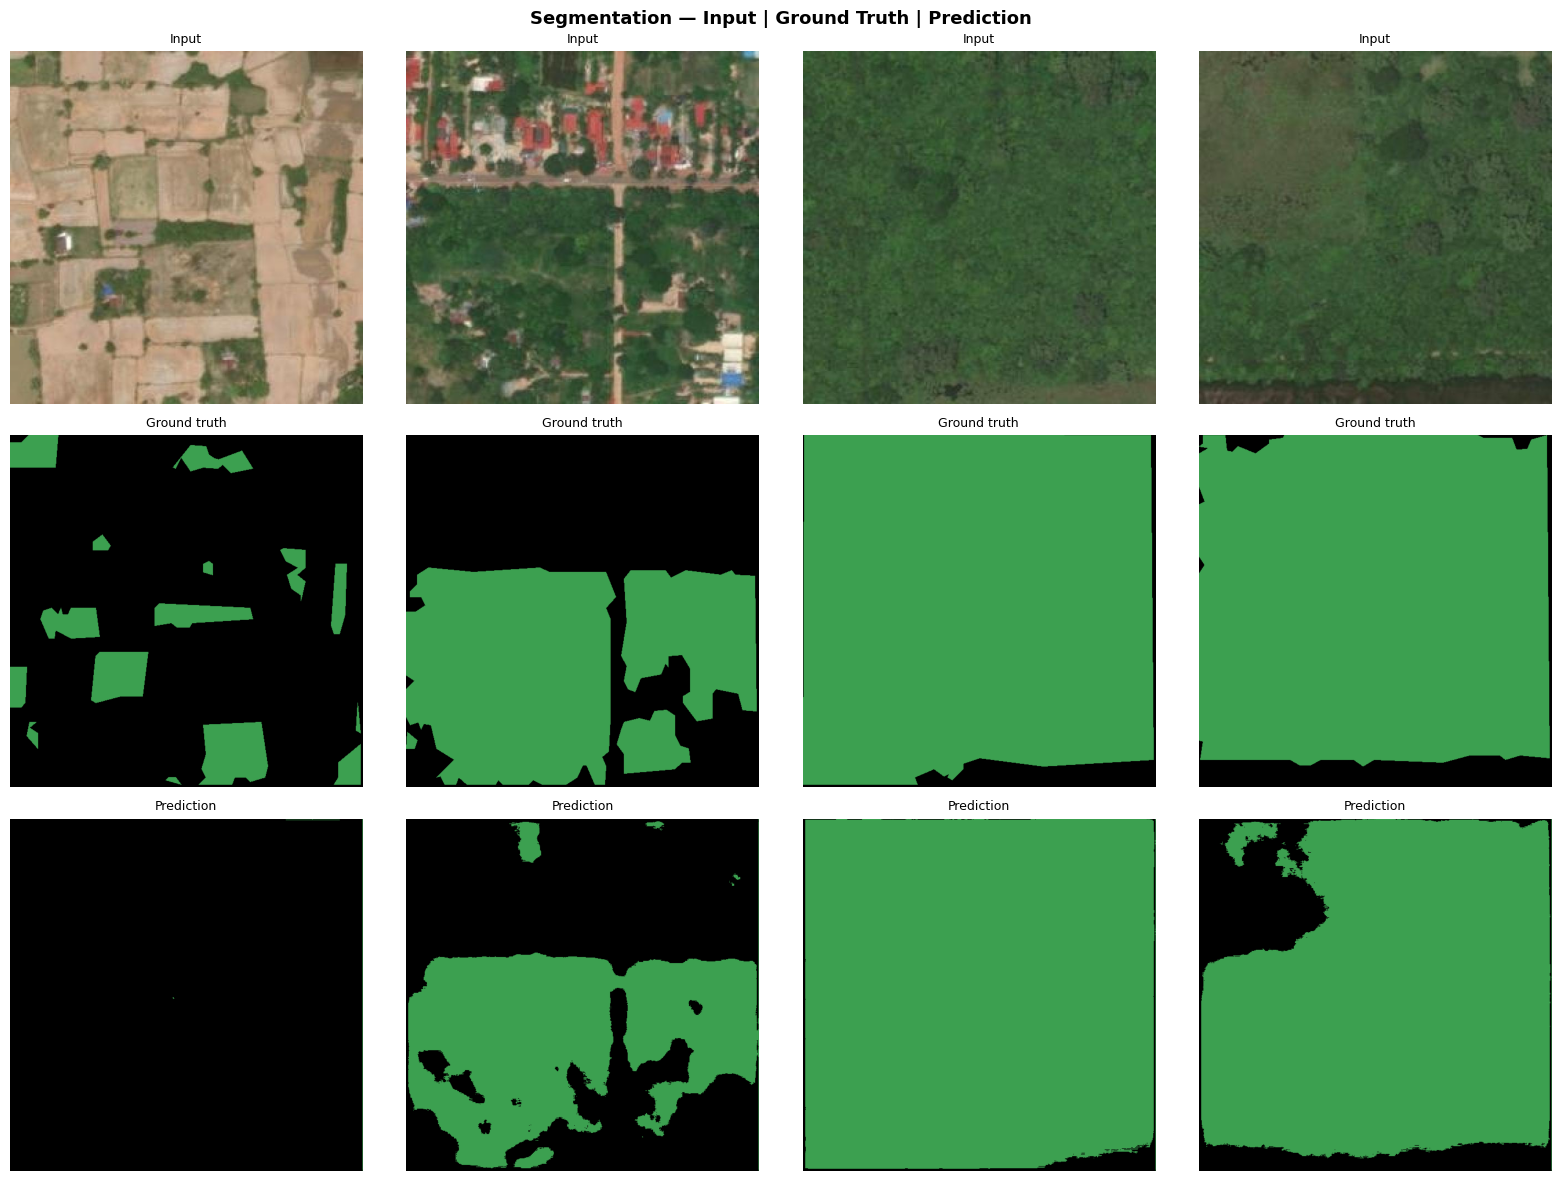

✅ Predictions saved!


In [ ]:
# ── Fix for PyTorch 2.6 UnpicklingError ──────────────────
import torch.serialization
try:
    import numpy._core.multiarray
    torch.serialization.add_safe_globals([
        numpy._core.multiarray.scalar,
        numpy._core.multiarray._reconstruct,
    ])
except: pass

def load_ckpt_safe(path,device):
    """Load checkpoint safely across PyTorch versions."""
    try:
        return torch.load(path,map_location=device,weights_only=False)
    except:
        try: return torch.load(path,map_location=device,weights_only=True)
        except:
            import numpy._core.multiarray as npcma
            with torch.serialization.safe_globals([npcma.scalar]):
                return torch.load(path,map_location=device,weights_only=True)

# ── Load best checkpoint ───────────────────────────────────
ckpt_path=f'{SEG_CKPT_DIR}/best_seg_model.pth'
if not os.path.exists(ckpt_path):
    found=glob.glob(f'{SEG_CKPT_DIR}/**/*.pth',recursive=True)
    ckpt_path=found[0] if found else None
if ckpt_path is None:
    raise FileNotFoundError('No checkpoint found — run Step 7 first.')

print(f'Loading: {ckpt_path}')
ckpt=load_ckpt_safe(ckpt_path,DEVICE)

# Rebuild model
if MODEL_TYPE=='unet':
    seg_model=smp.Unet(encoder_name=ENCODER,encoder_weights=None,
                       in_channels=3,classes=NUM_SEG_CLASSES,activation=None)
else:
    seg_model=smp.DeepLabV3Plus(encoder_name=ENCODER,encoder_weights=None,
                                in_channels=3,classes=NUM_SEG_CLASSES,activation=None)
seg_model=seg_model.to(DEVICE)

if isinstance(ckpt,dict) and 'model_state' in ckpt:
    seg_model.load_state_dict(ckpt['model_state'])
    print(f'  Epoch:{ckpt.get("epoch","?")} | Val IoU:{ckpt.get("val_iou","?")}')
elif isinstance(ckpt,dict) and 'state_dict' in ckpt:
    seg_model.load_state_dict(ckpt['state_dict'])
else:
    seg_model.load_state_dict(ckpt)
seg_model.eval()
print('✅ Checkpoint loaded!')

# ── Test evaluation ────────────────────────────────────────
test_iou=test_dice=0.0; nb=0
with torch.no_grad():
    for imgs,masks in tqdm(test_loader,desc='Testing'):
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        out=seg_model(imgs)
        test_iou +=compute_iou(out,masks,NUM_SEG_CLASSES)
        test_dice+=compute_dice(out,masks,NUM_SEG_CLASSES)
        nb+=1
nb=max(nb,1); test_iou/=nb; test_dice/=nb

print(f'\n{"="*45}')
print(f'  SEGMENTATION — FINAL TEST RESULTS')
print(f'{"="*45}')
print(f'  Mean IoU   : {test_iou:.4f}  (target > 0.70)')
print(f'  Dice Score : {test_dice:.4f}  (target > 0.75)')
print(f'{"="*45}')

# ── Training curves ────────────────────────────────────────
if history and len(history.get('train_loss',[]))>0:
    ep=range(1,len(history['train_loss'])+1)
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    fig.suptitle(f'{MODEL_TYPE.upper()} Training History',fontsize=13,fontweight='bold')
    axes[0].plot(ep,history['train_loss'],color='#E24B4A',label='Train')
    axes[0].plot(ep,history['val_loss'],  color='#378ADD',label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ep,history['val_iou'],color='#1D9E75',marker='o',markersize=3)
    axes[1].axhline(max(history['val_iou']),color='red',linestyle='--',
                    label=f'Best:{max(history["val_iou"]):.4f}')
    axes[1].set_title('Val IoU'); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(ep,history['val_dice'],color='#7F77DD',marker='s',markersize=3)
    axes[2].axhline(max(history['val_dice']),color='red',linestyle='--',
                    label=f'Best:{max(history["val_dice"]):.4f}')
    axes[2].set_title('Val Dice'); axes[2].legend(); axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{SEG_RESULTS_DIR}/training_curves.png',dpi=150,bbox_inches='tight')
    plt.show()
    print('✅ Training curves saved!')
else:
    print('⚠️ History not in memory — curves skipped.')

# ── Visualise predictions ──────────────────────────────────
imgs_b,masks_b=next(iter(test_loader))
with torch.no_grad():
    preds=seg_model(imgs_b.to(DEVICE)).argmax(dim=1).cpu()
n=min(4,len(imgs_b))
fig,axes=plt.subplots(3,n,figsize=(4*n,12))
if n==1: axes=axes.reshape(3,1)
fig.suptitle('Segmentation — Input | Ground Truth | Prediction',fontsize=13,fontweight='bold')
for i in range(n):
    axes[0,i].imshow(denormalize(imgs_b[i])); axes[0,i].set_title('Input',fontsize=9); axes[0,i].axis('off')
    axes[1,i].imshow(mask_to_rgb(masks_b[i].numpy())); axes[1,i].set_title('Ground truth',fontsize=9); axes[1,i].axis('off')
    axes[2,i].imshow(mask_to_rgb(preds[i].numpy())); axes[2,i].set_title('Prediction',fontsize=9); axes[2,i].axis('off')
plt.tight_layout()
plt.savefig(f'{SEG_RESULTS_DIR}/test_predictions.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ Predictions saved!')


---
## 🔍 Step 9 — Verify Detection Dataset & data.yaml

In [ ]:
import yaml

if not os.path.exists(YAML_PATH):
    print('⚠️ data.yaml not found — regenerating...')
    yolo_cfg={'path':DET_SPLIT_DIR,'train':'train/images','val':'val/images',
              'test':'test/images','nc':NUM_DET_CLASSES,'names':DET_CLASSES}
    YAML_PATH=f'{M2_DIR}/detection/artifacts_data.yaml'
    os.makedirs(os.path.dirname(YAML_PATH),exist_ok=True)
    with open(YAML_PATH,'w') as f: yaml.dump(yolo_cfg,f,default_flow_style=False)
    print(f'  Saved: {YAML_PATH}')

with open(YAML_PATH) as f: yolo_cfg=yaml.safe_load(f)
print('data.yaml:')
for k,v in yolo_cfg.items(): print(f'  {k}: {v}')

exts=('.jpg','.jpeg','.png','.bmp')
print('\nImage counts:')
for s in ['train','val','test']:
    n=len([f for f in glob.glob(f'{DET_SPLIT_DIR}/{s}/**/*',recursive=True)
           if f.lower().endswith(exts)])
    print(f'  {s:<8}: {n} images')
print('✅ Detection dataset verified!')


data.yaml:
  names: ['artifacts']
  nc: 1
  path: /content/archaeological_project/split/detection
  test: test/images
  train: train/images
  val: val/images

Image counts:
  train   : 18 images
  val     : 5 images
  test    : 2 images
✅ Detection dataset verified!


---
## 🚀 Step 10 — Train YOLOv5 Artifact Detector

In [ ]:
from ultralytics import YOLO

YOLO_MODEL='yolov5s.pt'
YOLO_EPOCHS=50
YOLO_IMGSZ=640
YOLO_BATCH=8

det_model=YOLO(YOLO_MODEL)
print(f'✅ Loaded: {YOLO_MODEL}')
print(f'   Training for {YOLO_EPOCHS} epochs')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

✅ Loaded: yolov5s.pt
   Training for 50 epochs


In [ ]:
results=det_model.train(
    data     =YAML_PATH,
    epochs   =YOLO_EPOCHS,
    imgsz    =YOLO_IMGSZ,
    batch    =YOLO_BATCH,
    device   =0 if DEVICE=='cuda' else 'cpu',
    project  =DET_CKPT_DIR,
    name     ='yolo_artifacts',
    exist_ok =True,
    patience =10,
    save     =True,
    plots    =True,
    optimizer='AdamW',
    lr0      =1e-3,
    cos_lr   =True,
    seed     =SEED,
)
print('\n✅ YOLOv5 training complete!')
print(f'   Best weights: {DET_CKPT_DIR}/yolo_artifacts/weights/best.pt')


Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/archaeological_project/processed/artifacts_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov5s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_artifacts, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap

---
## 📊 Step 11 — Evaluate Detection (mAP, Precision, Recall)

In [ ]:
best_weights=f'{DET_CKPT_DIR}/yolo_artifacts/weights/best.pt'
if os.path.exists(best_weights):
    best_det_model=YOLO(best_weights)
    print(f'✅ Loaded best weights')
else:
    best_det_model=det_model
    print('⚠️ Using last model — best.pt not found')

val_metrics=best_det_model.val(data=YAML_PATH,imgsz=YOLO_IMGSZ,
                               batch=YOLO_BATCH,device=0 if DEVICE=='cuda' else 'cpu')

print('\n📊 Detection Evaluation Results')
print('='*45)
try:
    box=val_metrics.box
    print(f'  mAP@0.5      : {box.map50:.4f}  (target > 0.50)')
    print(f'  mAP@0.5:0.95 : {box.map:.4f}')
    print(f'  Precision    : {box.mp:.4f}    (target > 0.70)')
    print(f'  Recall       : {box.mr:.4f}    (target > 0.70)')
    if hasattr(box,'ap_class_index') and box.ap_class_index is not None:
        print('\n  Per-class AP@0.5:')
        for i,ap in zip(box.ap_class_index,box.ap50):
            name=DET_CLASSES[i] if i<len(DET_CLASSES) else f'class_{i}'
            print(f'    {name:<20}: {ap:.4f}')
except Exception as e:
    print(f'  Note: {e}')


✅ Loaded best weights
Ultralytics 8.4.32 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv5s summary (fused): 85 layers, 9,111,923 parameters, 0 gradients, 23.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1328.3±610.3 MB/s, size: 40.7 KB)
val: Scanning /content/archaeological_project/split/detection/val/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 8.7it/s 0.1s
                   all          5          5      0.989          1      0.995      0.698
Speed: 0.8ms preprocess, 12.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val

📊 Detection Evaluation Results
  mAP@0.5      : 0.9950  (target > 0.50)
  mAP@0.5:0.95 : 0.6982
  Precision    : 0.9890    (target > 0.70)
  Recall       : 1.0000    (target > 0.70)

  Per-class AP@0.5:
    artifacts           : 0.995

---
## 👁️ Step 12 — Visualise Detection Predictions

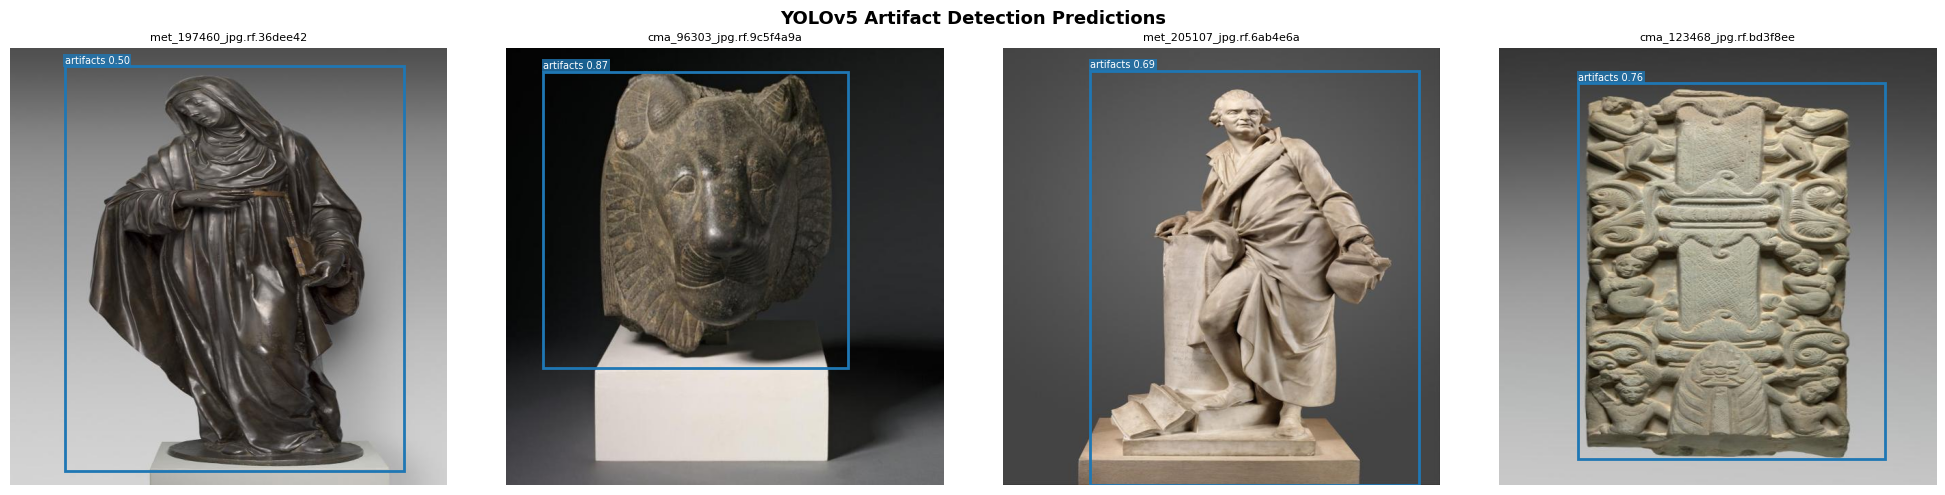

✅ Detection predictions saved!


In [ ]:
IMG_EXTS=('.jpg','.jpeg','.png','.bmp')

def visualize_yolo_preds(model,img_dir,n=4,conf=0.25,save_path=None):
    img_files=[f for f in glob.glob(f'{img_dir}/**/*',recursive=True)
               if f.lower().endswith(IMG_EXTS)]
    if not img_files: print('⚠️ No images found'); return
    samples=random.sample(img_files,min(n,len(img_files)))
    fig,axes=plt.subplots(1,len(samples),figsize=(5*len(samples),5))
    if len(samples)==1: axes=[axes]
    fig.suptitle('YOLOv5 Artifact Detection Predictions',fontsize=13,fontweight='bold')
    colors=plt.cm.tab10(np.linspace(0,1,max(len(DET_CLASSES),10)))
    for ax,ip in zip(axes,samples):
        res=model.predict(ip,conf=conf,verbose=False)[0]
        img_rgb=cv2.cvtColor(cv2.imread(ip),cv2.COLOR_BGR2RGB)
        H,W=img_rgb.shape[:2]; ax.imshow(img_rgb)
        if res.boxes and len(res.boxes):
            for box in res.boxes:
                x1,y1,x2,y2=box.xyxy[0].cpu().numpy()
                cls=int(box.cls[0]); cv=float(box.conf[0])
                col=colors[cls%len(colors)]
                ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,linewidth=2,edgecolor=col,facecolor='none'))
                name=DET_CLASSES[cls] if cls<len(DET_CLASSES) else f'cls_{cls}'
                ax.text(x1,y1-4,f'{name} {cv:.2f}',fontsize=7,color='white',
                        bbox=dict(facecolor=col,alpha=0.8,pad=1,edgecolor='none'))
        ax.set_title(Path(ip).name[:25],fontsize=8); ax.axis('off')
    plt.tight_layout()
    if save_path: plt.savefig(save_path,dpi=150,bbox_inches='tight')
    plt.show()

val_img_dir=os.path.join(DET_SPLIT_DIR,'val','images')
if not os.path.exists(val_img_dir): val_img_dir=os.path.join(DET_SPLIT_DIR,'val')
visualize_yolo_preds(best_det_model,val_img_dir,n=4,conf=0.25,
                     save_path=f'{DET_RESULTS_DIR}/detection_predictions.png')
print('✅ Detection predictions saved!')


---
## 💾 Step 13 — Save Metrics & Backup to Drive

In [ ]:
import shutil
m2_metrics={
    'milestone':2,
    'segmentation':{'model':MODEL_TYPE,'encoder':ENCODER,
                    'test_iou':round(test_iou,4),'test_dice':round(test_dice,4),
                    'checkpoint':'best_seg_model.pth'},
    'detection':{'model':YOLO_MODEL,'epochs':YOLO_EPOCHS,
                 'best_weights':'yolo_artifacts/weights/best.pt'},
}
try:
    box=val_metrics.box
    m2_metrics['detection'].update({'map50':round(float(box.map50),4),
                                    'precision':round(float(box.mp),4),
                                    'recall':round(float(box.mr),4)})
except: pass

m2_path=f'{M2_DIR}/milestone2_metrics.json'
with open(m2_path,'w') as f: json.dump(m2_metrics,f,indent=2)
print('✅ Metrics saved:', m2_path)

# ── Backup to Google Drive ─────────────────────────────────
DRIVE_M2_OUT = '/content/drive/MyDrive/Archaeological_AI/Milestone2_Output'
os.makedirs(DRIVE_M2_OUT, exist_ok=True)

# Copy result images
for fn in (glob.glob(f'{SEG_RESULTS_DIR}/*') +
           glob.glob(f'{DET_RESULTS_DIR}/*') + [m2_path]):
    if os.path.isfile(fn): shutil.copy2(fn, DRIVE_M2_OUT)

# CRITICAL: copy model weights so M4 can find them
best_seg = f'{SEG_CKPT_DIR}/best_seg_model.pth'
if os.path.exists(best_seg):
    shutil.copy2(best_seg, DRIVE_M2_OUT)
    print(f'✅ best_seg_model.pth → Drive')
else:
    print('⚠️  best_seg_model.pth not found — run Step 7 first')

# Copy YOLO weights folder
yolo_weights_src = f'{DET_CKPT_DIR}/yolo_artifacts/weights'
yolo_weights_dst = f'{DRIVE_M2_OUT}/yolo_artifacts/weights'
if os.path.exists(yolo_weights_src):
    os.makedirs(yolo_weights_dst, exist_ok=True)
    for wf in glob.glob(f'{yolo_weights_src}/*.pt'):
        shutil.copy2(wf, yolo_weights_dst)
    print(f'✅ YOLO weights → Drive')
else:
    print('⚠️  YOLO weights not found — run Step 10 first')

print(f'\n✅ M2 backup complete: {DRIVE_M2_OUT}')
print('   Files in Drive M2 folder:')
for fn in glob.glob(f'{DRIVE_M2_OUT}/**/*', recursive=True):
    if os.path.isfile(fn): print(f'   • {fn[len(DRIVE_M2_OUT):]}')


✅ Metrics saved: /content/archaeological_project/milestone2/milestone2_metrics.json
✅ best_seg_model.pth → Drive
✅ YOLO weights → Drive

✅ M2 backup complete: /content/drive/MyDrive/Archaeological_AI/Milestone2_Output
   Files in Drive M2 folder:
   • /batch_preview.png
   • /best_seg_model.pth
   • /training_curves.png
   • /test_predictions.png
   • /detection_predictions.png
   • /milestone2_metrics.json
   • /yolo_artifacts/weights/best.pt
   • /yolo_artifacts/weights/last.pt


---
## ✅ Milestone 2 Complete!
| Step | Task | Score |
|------|------|-------|
| 3 | Dataset & DataLoader | ✅ |
| 4 | Visualise batch | ✅ |
| 5 | U-Net model | ✅ |
| 6 | Loss + optimizer | ✅ |
| 7 | Train segmentation | **IoU, Dice** |
| 8 | Evaluate + curves | **IoU, Dice** |
| 9 | Verify YOLO data | ✅ |
| 10 | Train YOLOv5 | ✅ |
| 11 | Evaluate detection | **mAP, P, R** |
| 12 | Visualise predictions | ✅ |
| 13 | Save + Drive backup | ✅ |
